In [3]:
import warnings
warnings.filterwarnings('ignore')

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import csv
import os
import subprocess
from tqdm import tqdm_notebook
import pprint
import librosa
from IPython.display import clear_output
from scipy.ndimage import convolve
import music21
import madmom
from scipy.signal import convolve2d
from scipy.stats import linregress
from multiprocessing import Pool
import yaml
import pickle
import mido
from mido import MidiFile

from msmd.midi_parser import notes_to_onsets, FPS
from msmd.data_model.piece import Piece
from msmd.alignments import align_score_to_performance

In [5]:
DATA_ROOT_REAL = '../real_dataset'

In [76]:
pieces = glob.glob(os.path.join(DATA_ROOT_REAL, 'pickle', '*'))

In [218]:
def downsampleImage(strip, ratio):
    return np.array([[x[i] for i in range(len(x)) if i%ratio == 0] for x in strip])

def getMidiNoteEvents(midifile, fs = 100):
    mid = MidiFile(midifile)
    tempo = 500000 # default microseconds per beat
    curTimeSec = 0.0
    allEvents = []
    noteEvents = []
    
    for i, track in enumerate(mid.tracks):
        events_temp = []
        curTimeTick = 0
        for msg in track:
            curTimeTick += msg.time
            if msg.type == 'set_tempo':
                tempo = msg.tempo
                events_temp.append(('tempo',curTimeTick, tempo))
            if msg.type == 'note_on' and msg.velocity > 0:
                events_temp.append(('note',curTimeTick, msg.note))
            if msg.type == 'text' and '!!!END:' in msg.text: # ignore command messages that add time at end
                break 
        allEvents = allEvents + events_temp
    allEvents = sorted(allEvents, key=lambda x: x[1])
        
    # Convert accumulated time back to time difference
    allEvents_diff = []
    for i in range(len(allEvents)):
        if i == 0:
            allEvents_diff.append(allEvents[i])
        else:
            allEvents_diff.append((allEvents[i][0], allEvents[i][1]-allEvents[i-1][1], allEvents[i][2]))
    
    # Convert tick to second
    for event in allEvents_diff:
        curTimeSec += mido.tick2second(event[1], mid.ticks_per_beat, tempo)
        if event[0] == 'tempo':
            tempo = event[2]
        else:
            colIdx = np.int(np.round(curTimeSec * fs))
            noteEvents.append((colIdx, event[2]))
    return noteEvents

def calcErrorStats(errs_raw, tols, isSingle = False):
    if isSingle:
        errs = np.array(errs_raw)
    else:
        errs = np.array([err for sublist in errs_raw for err in sublist])
    errs = errs[~np.isnan(errs)] # when beat is not annotated, value is nan
    errorRates = []
    for tol in tols:
        toAdd = np.sum(np.abs(errs) > tol) * 1.0 / len(errs)
        errorRates.append(toAdd)
    
    avgError = np.average(np.abs(errs))
    stdError = np.std(np.abs(errs))
    return errorRates, avgError, stdError

In [187]:
def processPiece(piece_idx, debug=False):
    piece = os.path.split(pieces[piece_idx])[1]

    # Load strips
    strips = None
    with open(os.path.join(DATA_ROOT_REAL, 'pickle', piece), 'rb') as f:
        strips = pickle.load(f)

    # Load sheet music annotation
    df = pd.read_csv(os.path.join(DATA_ROOT_REAL, 
                                  'sheet_annot', 
                                  '_'.join(piece.split('_')[:-1]) + '_beats.csv'))
    df = df[df['score'] == '_'.join(piece.split('_')[1:])]

    # Load wp
    dhyp = np.load(os.path.join(DATA_ROOT_REAL, 'output', piece, 'output.npy'))
    zeroPad = dhyp.item().get('zeroPad')
    timeMapping = dhyp.item().get('timeMapping')
    striplens = dhyp.item().get('striplens')
    wp = dhyp.item().get('wp')

    # sheet music ref
    striplens = [s.shape[1] for s in strips]
    pixelOffset = np.cumsum([0] + striplens)  # cumulative pixel offset for each strip
    stripsPerPage = [df.loc[df.page == i,'strip'].max() for i in range(df.page.max()+1) ]
    stripOffset = np.cumsum([0] + stripsPerPage)
    stripIdx = stripOffset[df.page] + df.strip - 1  # cumulative strip index
    hpixlocs = pixelOffset[stripIdx] + (df.hpixel * 300 // 72)
    ref1 = hpixlocs
    
    if debug:
        plt.imshow(strips[0])
        print(df.hpixel.tolist())
        plt.axvline(df.hpixel.tolist()[0] * 300 // 72)
        plt.axvline(df.hpixel.tolist()[1] * 300 // 72)
        plt.axvline(df.hpixel.tolist()[2] * 300 // 72)
        plt.axvline(df.hpixel.tolist()[20] * 300 // 72)
        plt.axvline(df.hpixel.tolist()[21] * 300 // 72)
        plt.show()
        plt.imshow(strips[1])
        plt.axvline(df.hpixel.tolist()[22] * 300 // 72)
        plt.show()
        print(hpixlocs)

    # Load MIDI annotation
    annot_file = os.path.join(DATA_ROOT_REAL, 
                              'midi_annot', 
                              '_'.join(piece.split('_')[:-1]) + '.csv')

    midiFile = os.path.join(DATA_ROOT_REAL, 
                            'midi', 
                            '_'.join(piece.split('_')[:-1]) + '.mid')

    # find optimal fs
    fs = 100.0
    noteEvents = getMidiNoteEvents(midiFile, fs)
    striplen = np.sum([s.shape[1] for s in strips])
    fs = np.int(fs * striplen / noteEvents[-1][0]) # adjust to get equal lengths

    timeStamps = []
    with open(annot_file, newline='') as csvfile:
        spamreader = csv.reader(csvfile, delimiter=',', quotechar='|')
        for row in spamreader:
            if row[0] != '-':
                timeStamps.append(float(row[0]))
            else:
                timeStamps.append(float('inf'))
    timeStamps = np.array(timeStamps)

    # convert to mapped frames
    frames = (timeStamps - timeStamps[0]) * fs
    mapped_frms = [i for i, elem in enumerate(timeMapping) if elem != -1]
    orig_frms = [elem for elem in timeMapping if elem != -1]
    orig_frms = np.array(orig_frms) - orig_frms[0]
    mapped_interp = np.interp(frames, orig_frms, mapped_frms)
    padded = mapped_interp + zeroPad

    sheet_ref_beats = hpixlocs
    midi_ref_beats = padded

    # calculate prediction errors [dtw]
    sheet_preds = wp[:,0]
    midi_preds = wp[:,1]
    hypFrames = np.interp(sheet_ref_beats, sheet_preds, midi_preds)
    hypPixels = np.interp(midi_ref_beats, midi_preds, sheet_preds)
    minLen = np.min((len(hypFrames), len(hypPixels)))
#     errsFrames = hypFrames[0:minLen] - midi_ref_beats[0:minLen]
#     errsTime = errsFrames * 1000.0 / fs  # in ms
    errsPixels_dtw = hypPixels[0:minLen] - sheet_ref_beats[0:minLen]    
    errorRate_dtw, _, _ = calcErrorStats(errsPixels_dtw, range(3000), isSingle = True)
    
    # calculate prediction errors [global linear]
    sheet_preds = wp[[0,-1],0]
    midi_preds = wp[[0,-1],1]
    hypFrames = np.interp(sheet_ref_beats, sheet_preds, midi_preds)
    hypPixels = np.interp(midi_ref_beats, midi_preds, sheet_preds)
    minLen = np.min((len(hypFrames), len(hypPixels)))
#     errsFrames = hypFrames[0:minLen] - midi_ref_beats[0:minLen]
#     errsTime = errsFrames * 1000.0 / fs  # in ms
    errsPixels_global_linear = hypPixels[0:minLen] - sheet_ref_beats[0:minLen]    
    errorRate_global_linear, _, _ = calcErrorStats(errsPixels_global_linear, range(3000), isSingle = True)
    
    if debug:
        plt.plot(errorRate_dtw, label='Ours')
        plt.plot(errorRate_global_linear, label='Global Linear')
        plt.title(piece)
        plt.ylim([0,1])
        plt.grid()
        plt.legend()
        plt.show()
    return (errsPixels_dtw, errsPixels_global_linear)

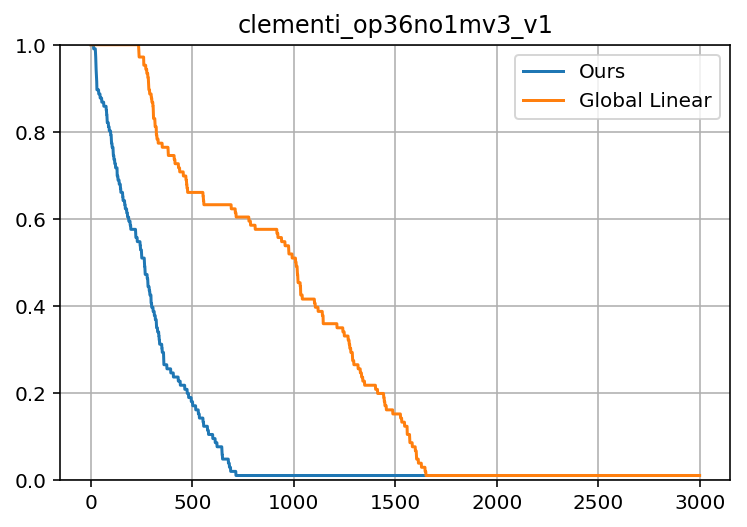

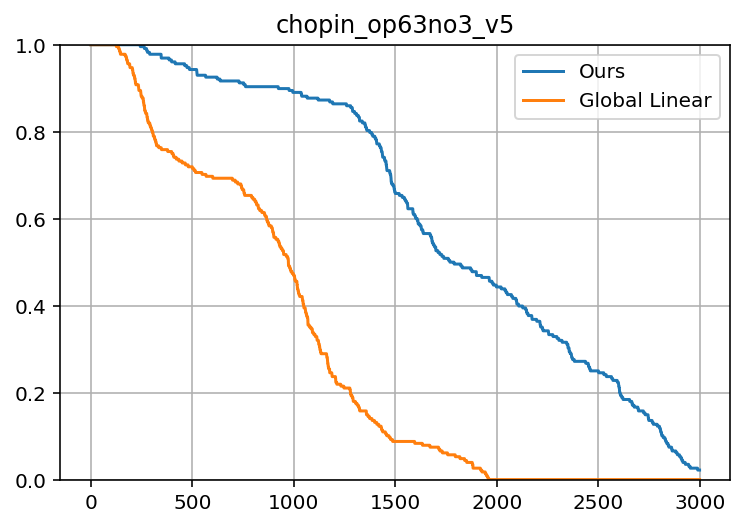

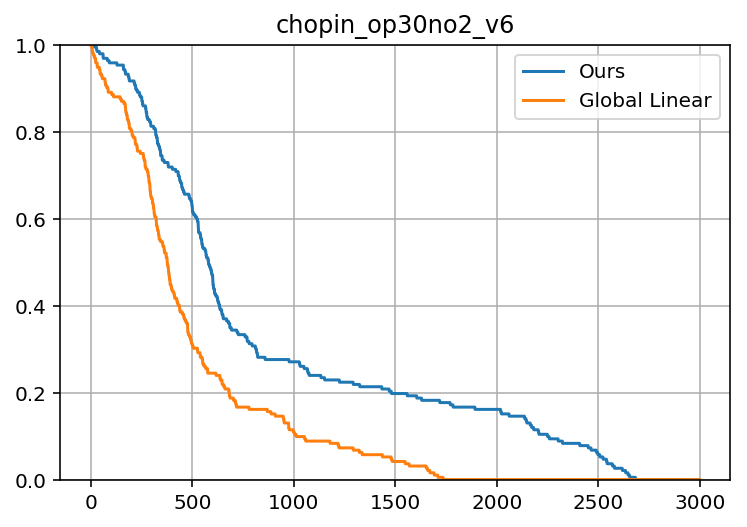

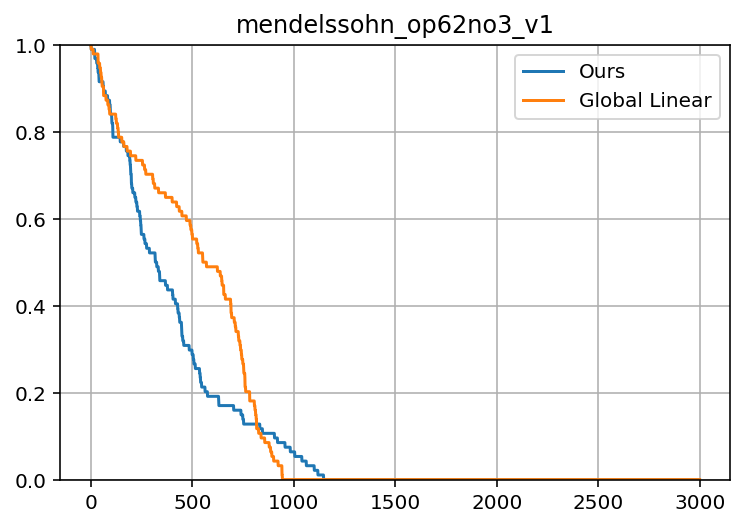

In [ ]:
output = []
for i in range(len(pieces)):
    output.append(processPiece(i, debug=False))

[83, 109, 126, 140, 165, 188, 202, 226, 242, 257, 284, 302, 315, 337, 352, 365, 393, 417, 433, 465, 489, 501, 33, 55, 70, 98, 115, 130, 158, 183, 197, 222, 238, 252, 278, 300, 319, 342, 360, 373, 401, 426, 440, 470, 486, 500, 33, 51, 67, 95, 109, 126, 150, 166, 184, 215, 241, 256, 276, 294, 312, 342, 358, 376, 400, 416, 435, 462, 479, 501, 31, 49, 66, 91, 111, 128, 153, 170, 189, 218, 244, 257, 280, 297, 314, 342, 358, 376, 401, 422, 440, 464, 481, 502, 32, 55, 69, 147, 172, 186, 203, 220, 233, 251, 271, 284, 303, 327, 345, 363, 389, 402, 421, 438, 453, 472, 494, 506, 37, 59, 78, 99, 124, 138, 159, 183, 196, 218, 244, 256, 280, 306, 327, 345, 374, 389, 408, 431, 445, 464, 486, 502, 41, 62, 73, 149, 165, 180, 206, 226, 241, 263, 279, 291, 312, 330, 341, 363, 379, 390, 414, 435, 449, 477, 492, 503, 32, 54, 74, 105, 124, 139, 169, 195, 213, 251, 269, 284, 315, 340, 356, 382, 405, 424, 460, 474, 496, 32, 55, 81, 114, 139, 154, 177, 192, 206, 235, 262, 292, 321, 342, 356, 386, 406, 428, 461

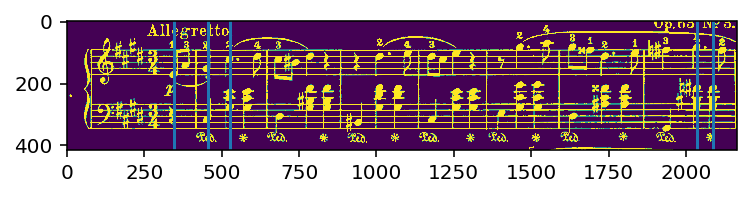

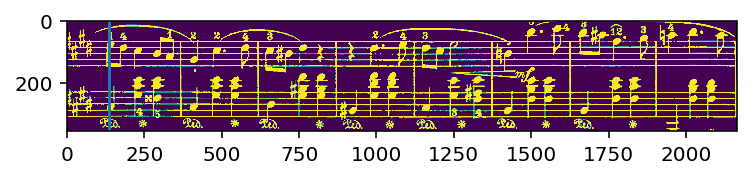

916       345
917       454
918       525
919       583
920       687
921       783
922       841
923       941
924      1008
925      1070
926      1183
927      1258
928      1312
929      1404
930      1466
931      1520
932      1637
933      1737
934      1804
935      1937
936      2037
937      2087
938      2301
939      2393
940      2455
941      2572
942      2643
943      2705
944      2822
945      2926
        ...  
1115    18589
1116    18677
1117    18735
1118    18860
1119    18943
1120    19035
1121    19172
1122    19260
1123    19318
1124    19537
1125    19637
1126    19741
1127    19874
1128    19949
1129    20012
1130    20145
1131    20245
1132    20337
1133    20437
1134    20512
1135    20591
1136    20708
1137    20808
1138    20883
1139    21037
1140    21104
1141    21208
1142    21320
1143    21412
1144    21474
Name: hpixel, Length: 229, dtype: int64


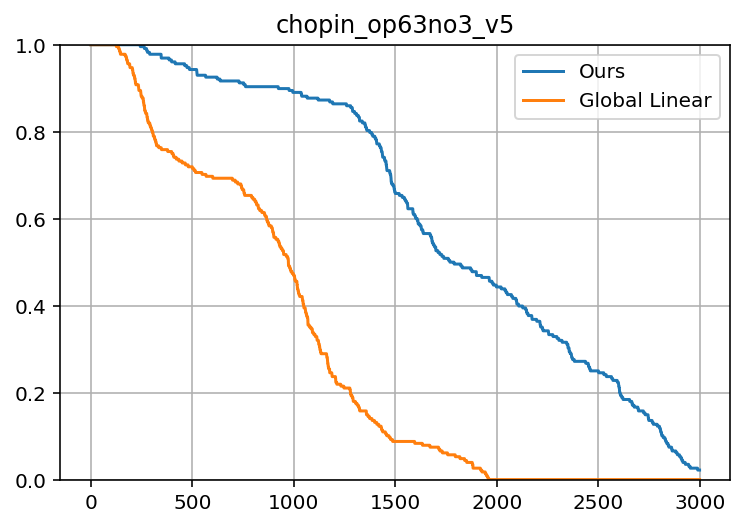

In [183]:
processPiece(1, debug=True)

In [221]:
def aggregateResult(output, tols=np.arange(100), 
                    markers=['.','v','^','x','D','h','*'],
                    debug=False):
    errs = []
    errs_global_linear = []
    
    for idx, each in enumerate(output):
        errs.extend(each[0].tolist())
        errs_global_linear.extend(each[1].tolist())
        
        if debug:
            errorRates, avgError, stdError = calcErrorStats(each[0].tolist(), tols, isSingle=True)    
            plt.plot(tols, errorRates, label='Ours')        
            errorRates, _, _ = calcErrorStats(each[1].tolist(), tols, isSingle=True)    
            plt.plot(tols, errorRates, label='Global Linear')       
            plt.grid()
            plt.legend(loc='best')
            plt.xlabel("Error Tolerance (px)")
            plt.ylabel("Error Rate")
            plt.ylim([0,1])
            plt.title("{} (avg = {:.2f}, std = {:.2f})".format(pieces[idx], avgError, stdError))
            plt.show()
            
    return (calcErrorStats(errs, tols, isSingle=True), calcErrorStats(errs_global_linear, tols, isSingle=True))

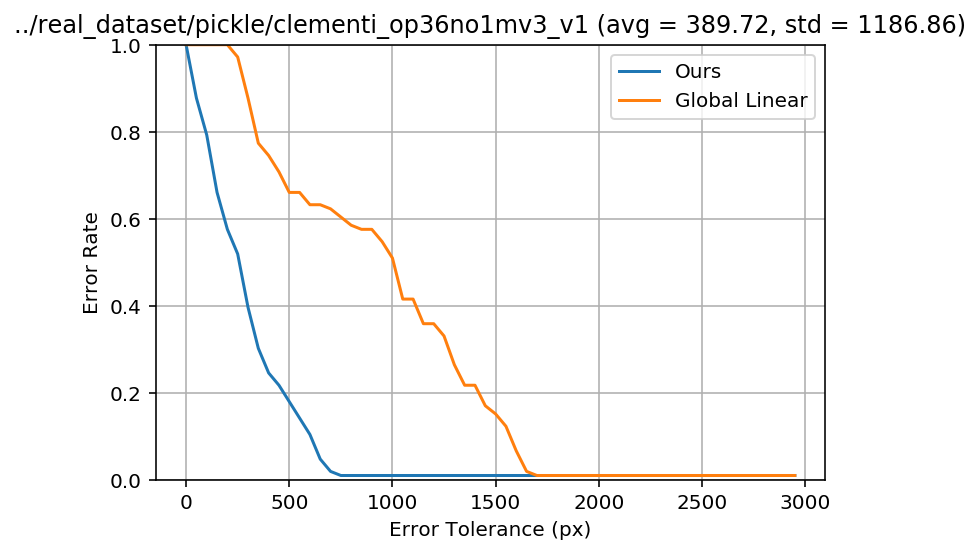

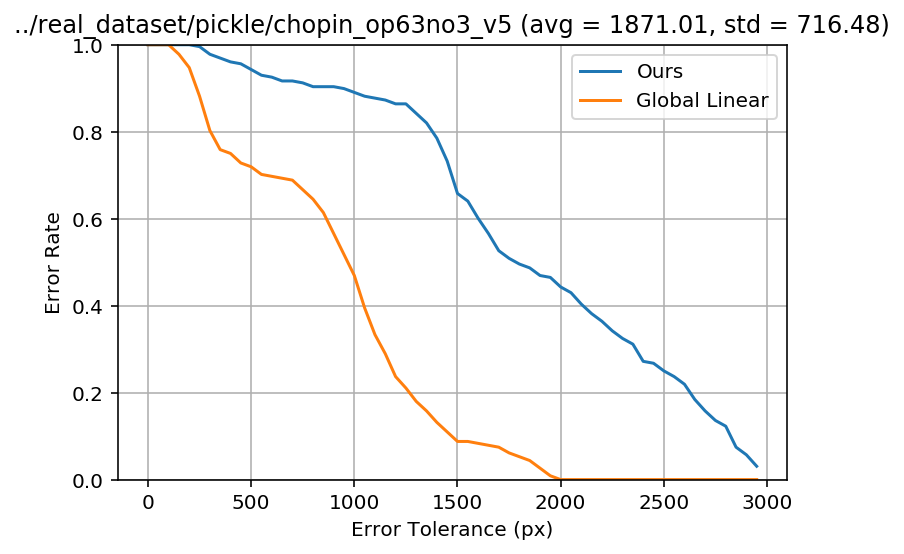

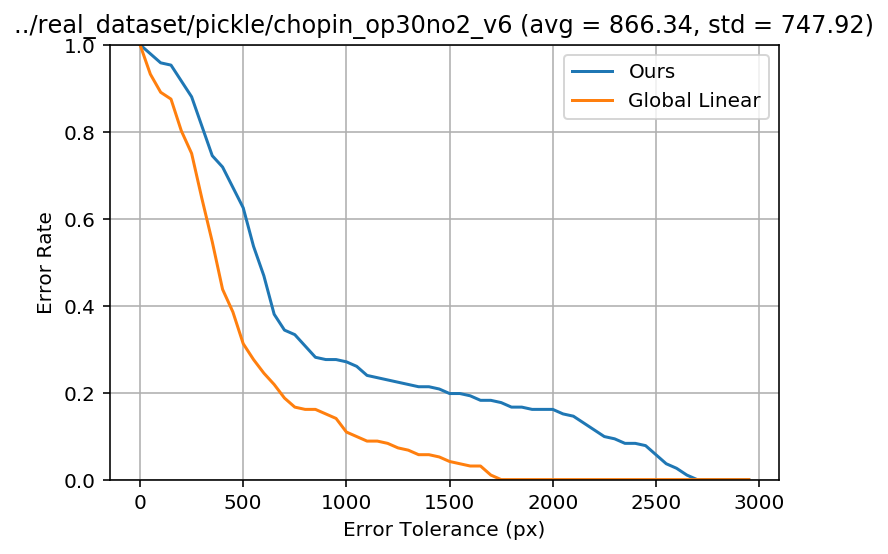

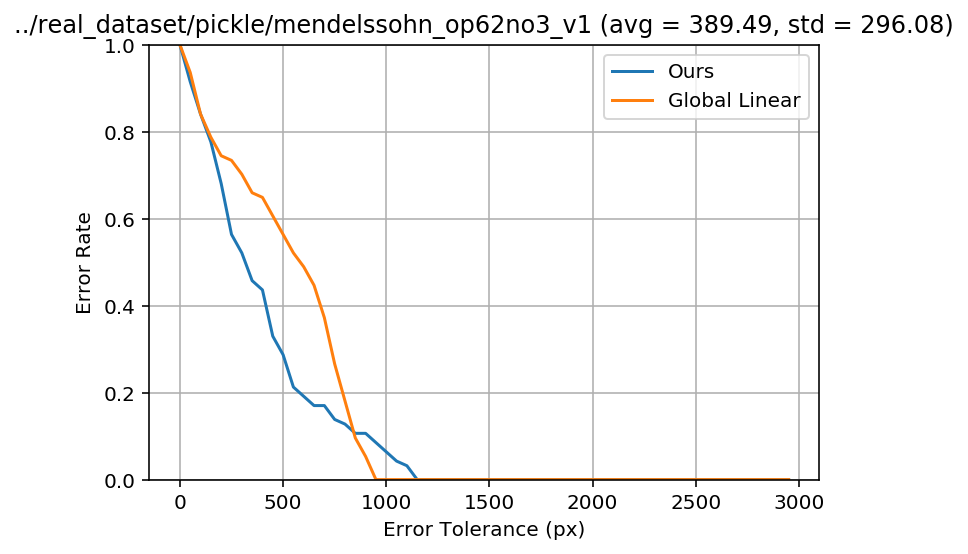

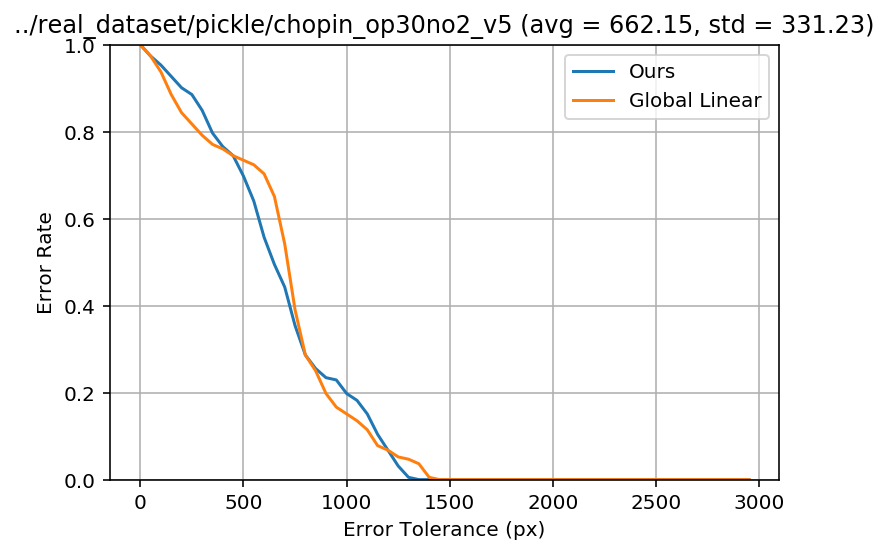

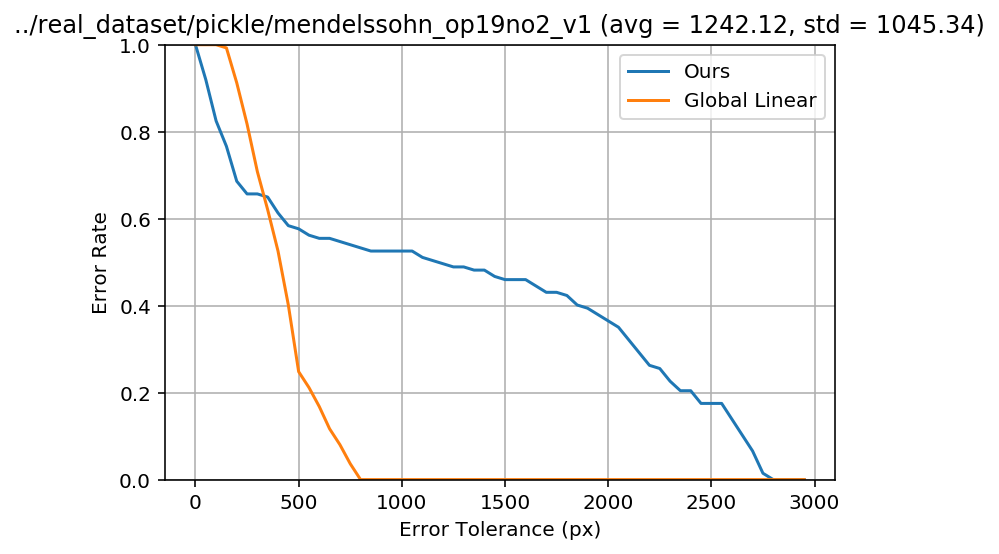

In [222]:
tols = np.arange(0,3000,50)
(ours, global_linear) = aggregateResult(output, tols, debug=True)

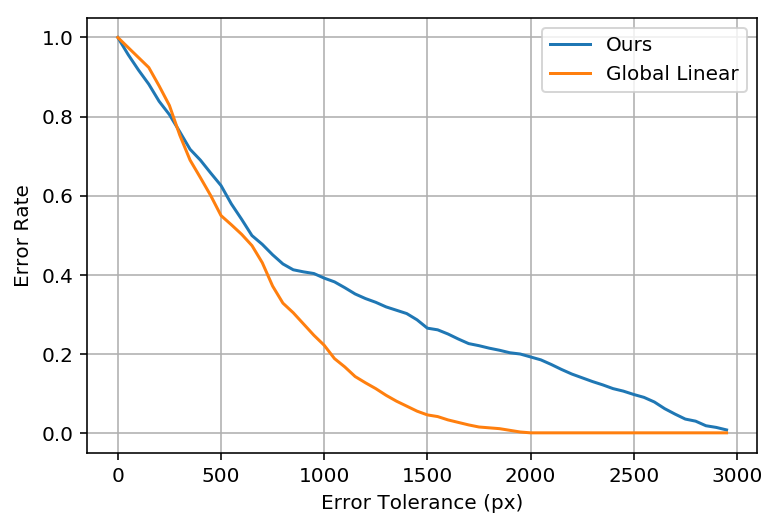

Ours: Average error: 1020.18 px (std = 937.03)
Global Linear: Average error: 673.82 px (std = 609.17)


In [223]:
plt.plot(tols, ours[0], label='Ours')
plt.plot(tols, global_linear[0], label='Global Linear')
plt.grid()
plt.legend()
plt.xlabel("Error Tolerance (px)")
plt.ylabel("Error Rate")
plt.show()
print("Ours: Average error: {:.2f} px (std = {:.2f})".format(ours[1], ours[2]))
print("Global Linear: Average error: {:.2f} px (std = {:.2f})".format(global_linear[1], global_linear[2]))